In [1]:
# Install
%pip install torch
%pip install torchvision

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import os

import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms

from MLP import FashionMLP
from Part1 import train

In [3]:
# Set seed
seed = 42
torch.manual_seed(seed)
# Set device to GPU if available, otherwise CPU
device = 'cpu'
if torch.cuda.is_available():
    device = 'cuda'
    torch.cuda.manual_seed(seed)

torch.set_num_threads(os.cpu_count())  # utiliser threads dispo pour accélerer sur cpu

print(f"Using device: {device}")
print(f"CPU threads used by torch: {torch.get_num_threads()}")

Using device: cpu
CPU threads used by torch: 16


In [4]:
# Préparation de données

# Normalement on aurait calculé la moyenne et l'écart-type de Fashion-MNIST, mais ici ils sont donnés
mean = 0.2860
std = 0.3530

# Voici la transformé pour expérience 2

transform_exp2 = transforms.Compose([
    transforms.Lambda(lambda img: torch.from_numpy(np.array(img)).float())
])

# Voici la transformé pour le reste des expériences
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((mean,), (std,))
])

# Transformée non normalisée (expérience 1)
transform_no_normalization = transforms.Compose([
    transforms.ToTensor()
])


def get_loaders(batch_size, transform):
    os.makedirs("./data", exist_ok=True)

    # Download and load training data
    train_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=True,
        transform=transform,
        download=True
    )

    # Download and load test data
    test_dataset = torchvision.datasets.FashionMNIST(
        root='./data',
        train=False,
        transform=transform,
        download=True
    )

    num_workers = 2

    train_loader = torch.utils.data.DataLoader(
        dataset=train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        pin_memory=False,
        persistent_workers=(num_workers > 0)
    )
    test_loader = torch.utils.data.DataLoader(
        dataset=test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        pin_memory=False,
        persistent_workers=(num_workers > 0)
    )
    return train_loader, test_loader


In [5]:
class_names = [
    'T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
    'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot'
]

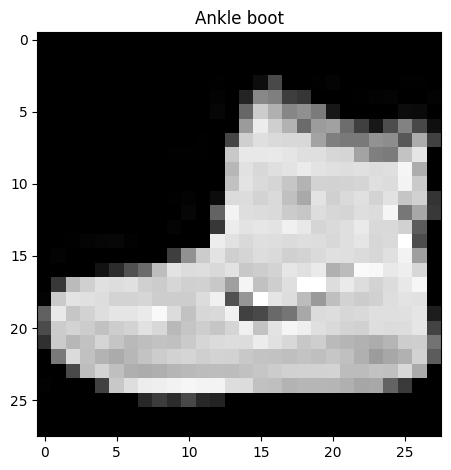

[[[-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01
   -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01]
  [-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01
   -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01]
  [-8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.1019837e-01 -8.10198

In [6]:
# Voyons un peu de quoi a l'air le jeu de données
train_dataset = torchvision.datasets.FashionMNIST(
    root='./data',
    train=True,
    transform=transform,
    download=True
)

np.set_printoptions(linewidth=350)

image_tensor, label_idx = train_dataset[0]
image_numpy = image_tensor.squeeze().numpy()
fig = plt.figure()
plt.imshow(image_numpy, cmap='gray')
plt.title(class_names[label_idx])
plt.tight_layout()
plt.show()
print(image_tensor.numpy())

In [7]:
# Loaders
train_loader_norm_64, test_loader_norm_64 = get_loaders(64, transform)
train_loader_nonorm_64, test_loader_nonorm_64 = get_loaders(64, transform_no_normalization)
train_loader_norm_8, test_loader_norm_8 = get_loaders(8, transform)

In [8]:
# Voici un fonction pour visualiser quelques exemples
def visualize_samples(dataset, num_samples=10):
    """
    Plots a grid of random images from the dataset with their labels.
    """
    fig = plt.figure(figsize=(12, 5))

    for i in range(num_samples):
        idx = np.random.randint(0, len(dataset))
        image_tensor, label_idx = dataset[idx]
        image_numpy = image_tensor.squeeze().numpy()
        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image_numpy, cmap='gray')
        ax.set_title(class_names[label_idx])
    plt.tight_layout()
    plt.show()

Total number of training images: 60000
Displaying random samples...


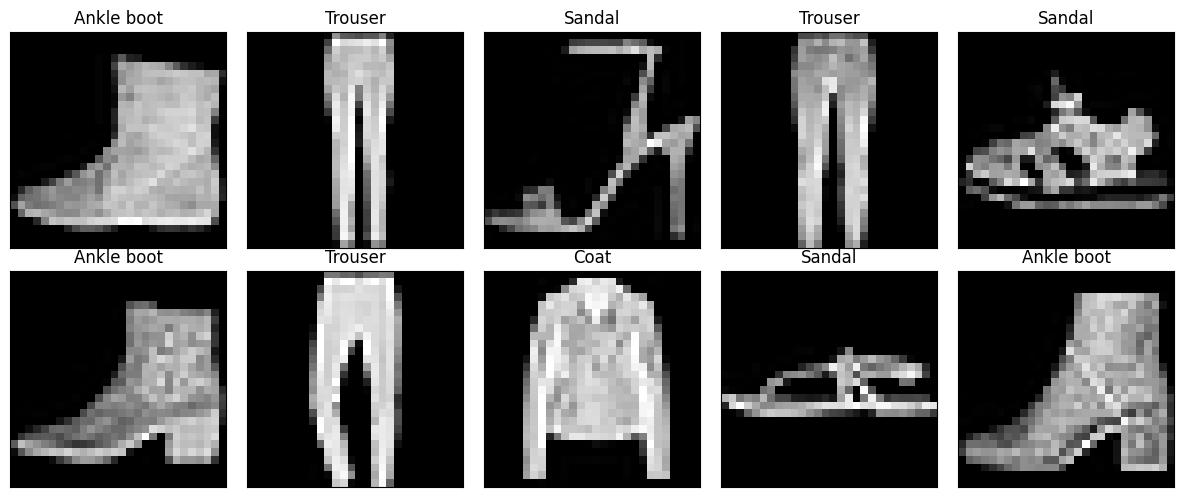

In [9]:
print(f"Total number of training images: {len(train_dataset)}")
print("Displaying random samples...")

visualize_samples(train_dataset, num_samples=10)

In [10]:
# Hyperparamètres d'entraînement
LEARNING_RATE = 0.05
EPOCHS = 20

In [11]:
# Hyperparamètres du modèle
INPUT_SIZE = 28 * 28
H1_SIZE = 64
H2_SIZE = 64
OUTPUT_SIZE = 10

ACTIVATION1 = nn.Sigmoid()
ACTIVATION2 = nn.Sigmoid()

In [12]:
model = FashionMLP(input_size=INPUT_SIZE,
                   h1_size=H1_SIZE,
                   h2_size=H2_SIZE,
                   output_size=OUTPUT_SIZE,
                   activation1=ACTIVATION1,
                   activation2=ACTIVATION2
                   ).to(device)
print(model)

FashionMLP(
  (flatten): Flatten(start_dim=1, end_dim=-1)
  (activation1): Sigmoid()
  (activation2): Sigmoid()
  (fc1): Linear(in_features=784, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=10, bias=True)
)


In [13]:
for param in model.parameters():
    print(type(param), param.size())

<class 'torch.nn.parameter.Parameter'> torch.Size([64, 784])
<class 'torch.nn.parameter.Parameter'> torch.Size([64])
<class 'torch.nn.parameter.Parameter'> torch.Size([64, 64])
<class 'torch.nn.parameter.Parameter'> torch.Size([64])
<class 'torch.nn.parameter.Parameter'> torch.Size([10, 64])
<class 'torch.nn.parameter.Parameter'> torch.Size([10])


In [14]:
def mse_los(outputs, labels):
    targets_one_hot = F.one_hot(labels, num_classes=outputs.size(1)).float()
    probs = F.softmax(outputs, dim=1)
    return F.mse_loss(probs, targets_one_hot)


def hinge_loss_simple(outputs, labels, margin=1.0):
    correct_scores = outputs.gather(1, labels.view(-1, 1))
    margins = outputs - correct_scores + margin
    loss = torch.max(torch.zeros_like(margins), margins)
    loss.scatter_(1, labels.view(-1, 1), 0)
    return loss.sum(1).mean()

In [15]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(),
                      lr=LEARNING_RATE)  # Nous utilisons SGD tel que vu en classe. Ne changer pas l'optimizer

In [16]:
train_losses, test_losses, train_accuracies, test_accuracies = train(
    model=model,
    epochs=EPOCHS,
    optimizer=optimizer,
    criterion=criterion,
    train_loader=train_loader_norm_64,  # batch size 64
    test_loader=test_loader_norm_64,  # batch size 64
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 1.6181 | Test Loss: 1.1171 | Train Accuracy: 44.61 | Test Accuracy: 59.54%
Epoch [5/20] | Train Loss: 0.5061 | Test Loss: 0.5081 | Train Accuracy: 82.20 | Test Accuracy: 81.64%
Epoch [10/20] | Train Loss: 0.3834 | Test Loss: 0.4204 | Train Accuracy: 86.38 | Test Accuracy: 84.69%
Epoch [15/20] | Train Loss: 0.3326 | Test Loss: 0.3838 | Train Accuracy: 88.17 | Test Accuracy: 85.99%
Epoch [20/20] | Train Loss: 0.3015 | Test Loss: 0.3858 | Train Accuracy: 89.25 | Test Accuracy: 86.35%


In [17]:
# Visualisation
def visualize(experiment, experiment_name, epochs):
    plt.figure(figsize=(12, 5))

    # Plot training loss
    plt.subplot(1, 2, 1)
    plt.plot(range(1, epochs + 1), experiment[0], marker='o', color='orange', label=f'{experiment_name} Train Loss')
    plt.plot(range(1, epochs + 1), experiment[1], marker='x', ls="--", color='orange',
             label=f'{experiment_name} Test Loss')
    plt.title('Training Loss over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.grid(True)
    plt.legend()

    # Plot test accuracy
    plt.subplot(1, 2, 2)
    plt.plot(range(1, epochs + 1), experiment[2], marker='o', color='orange', label=f'{experiment_name} train Accuracy')
    plt.plot(range(1, epochs + 1), experiment[3], marker='x', ls="--", color='orange',
             label=f'{experiment_name} Test Accuracy')
    plt.title('Test Accuracy over Epochs')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.legend()
    plt.grid(True)

    plt.tight_layout()
    plt.savefig(f'exp_{experiment_name}.png')
    plt.show()

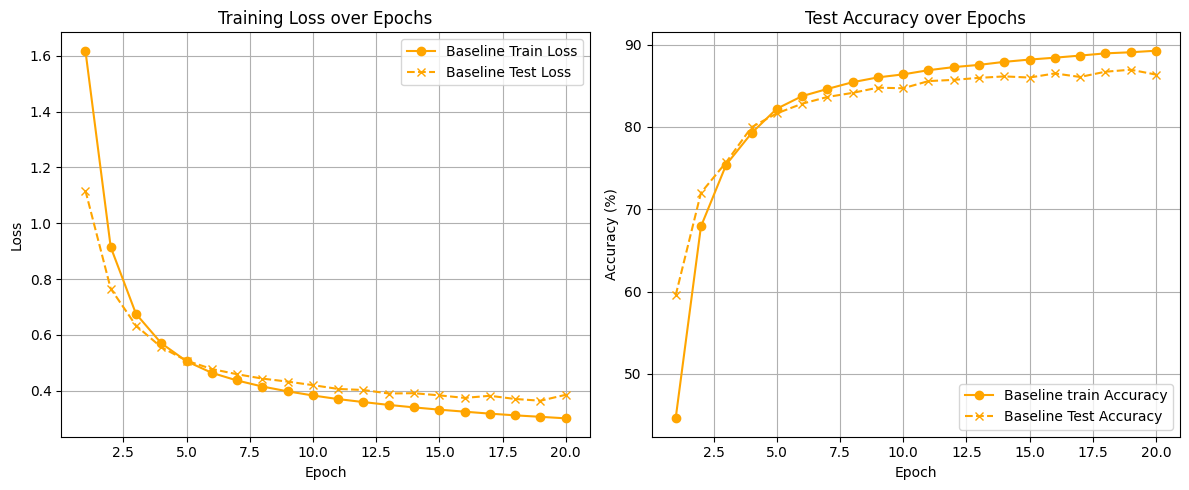

Baseline final test accuracy: 86.35
Baseline best test accuracy: 86.94


In [18]:
baseline_experiment = (train_losses, test_losses, train_accuracies, test_accuracies)
visualize(baseline_experiment, "Baseline", EPOCHS)

print("Baseline final test accuracy:", test_accuracies[-1])
print("Baseline best test accuracy:", max(test_accuracies))

In [19]:
# Une fonction sympa pour voir les exemples mal classifiés
def get_model_failures(model, loader, device):
    """
    Runs the model on the loader and returns a list of (image, true_label, predicted_label)
    for every instance where the model was wrong.
    """
    model.eval()
    failures = []

    print("Analyzing test set for failures...")
    with torch.no_grad():
        for images, labels in loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            mask = predicted != labels
            wrong_imgs = images[mask].cpu()
            wrong_labels = labels[mask].cpu()
            wrong_preds = predicted[mask].cpu()

            for i in range(len(wrong_imgs)):
                failures.append((wrong_imgs[i], wrong_labels[i].item(), wrong_preds[i].item()))

    print(f"Analysis complete. Model failed on {len(failures)} images.")
    return failures


def visualize_failures(failures, class_names, num_samples=10):
    """
    Specialized visualization for failures to show what the model
    thought the image was versus reality.
    """
    if not failures:
        print("No failures to display!")
        return

    num_samples = min(num_samples, len(failures))
    fig = plt.figure(figsize=(15, 7))

    indices = np.random.choice(len(failures), num_samples, replace=False)

    for i, idx in enumerate(indices):
        image_tensor, true_label, pred_label = failures[idx]

        image_numpy = image_tensor.squeeze().numpy()

        ax = fig.add_subplot(2, 5, i + 1, xticks=[], yticks=[])
        ax.imshow(image_numpy, cmap='gray')

        title = f"True: {class_names[true_label]}\nPred: {class_names[pred_label]}"
        ax.set_title(title, fontsize=10)

    plt.tight_layout()
    plt.suptitle("Model Misclassifications", fontsize=16, y=1.05)
    plt.show()

In [20]:
failed_data = get_model_failures(model, test_loader_norm_64, device)

Analyzing test set for failures...
Analysis complete. Model failed on 1365 images.


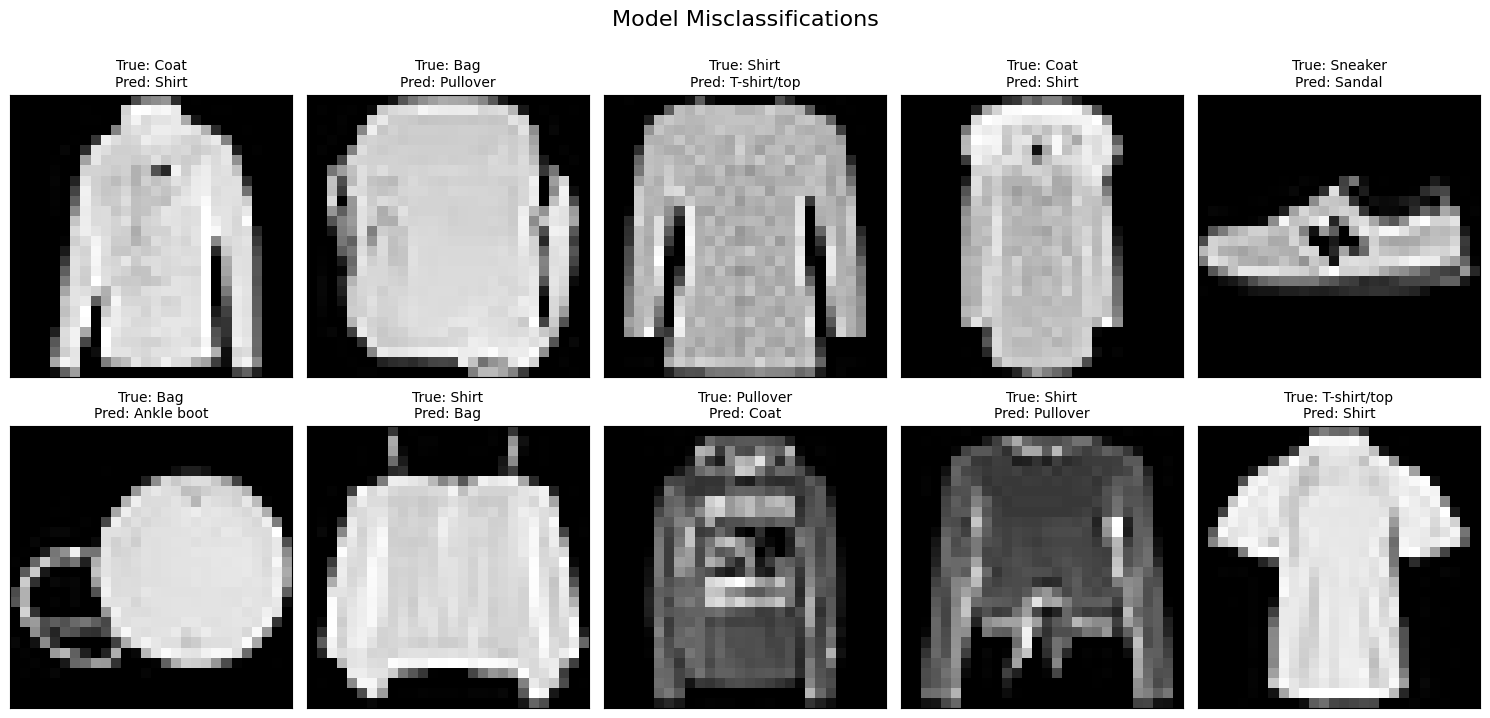

In [21]:
visualize_failures(failed_data, class_names, num_samples=10)

In [22]:
# Résumé
results_summary = []

results_summary.append({
    "Experiment": "Baseline",
    "Final Train Loss": baseline_experiment[0][-1],
    "Final Test Loss": baseline_experiment[1][-1],
    "Final Train Accuracy": baseline_experiment[2][-1],
    "Final Test Accuracy": baseline_experiment[3][-1],
    "Best Test Accuracy": max(baseline_experiment[3])
})

## Experience 1

In [23]:
model_exp1 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp1 = nn.CrossEntropyLoss()
optimizer_exp1 = optim.SGD(model_exp1.parameters(), lr=0.05)

exp1 = train(
    model=model_exp1,
    epochs=20,
    optimizer=optimizer_exp1,
    criterion=criterion_exp1,
    train_loader=train_loader_nonorm_64,
    test_loader=test_loader_nonorm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 2.1494 | Test Loss: 1.6543 | Train Accuracy: 26.05 | Test Accuracy: 44.10%
Epoch [5/20] | Train Loss: 0.7159 | Test Loss: 0.6919 | Train Accuracy: 74.06 | Test Accuracy: 74.97%
Epoch [10/20] | Train Loss: 0.5083 | Test Loss: 0.5253 | Train Accuracy: 82.08 | Test Accuracy: 81.18%
Epoch [15/20] | Train Loss: 0.4353 | Test Loss: 0.4696 | Train Accuracy: 84.59 | Test Accuracy: 83.06%
Epoch [20/20] | Train Loss: 0.3971 | Test Loss: 0.4553 | Train Accuracy: 85.88 | Test Accuracy: 83.97%


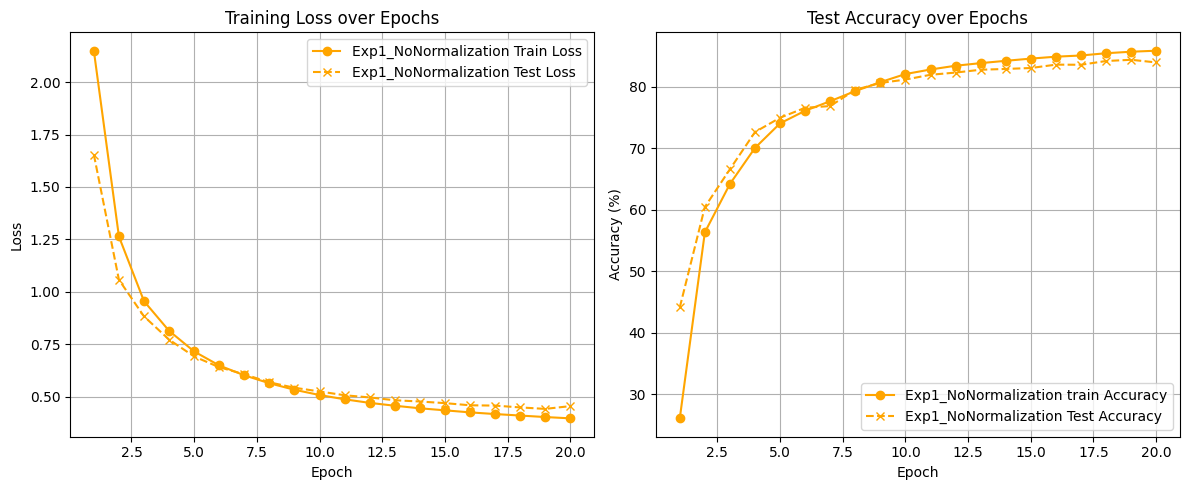

Exp1 final test accuracy: 83.97
Exp1 best test accuracy: 84.4


In [24]:
visualize(exp1, "Exp1_NoNormalization", 20)

print("Exp1 final test accuracy:", exp1[3][-1])
print("Exp1 best test accuracy:", max(exp1[3]))

results_summary.append({
    "Experiment": "Exp1_NoNormalization",
    "Final Train Loss": exp1[0][-1],
    "Final Test Loss": exp1[1][-1],
    "Final Train Accuracy": exp1[2][-1],
    "Final Test Accuracy": exp1[3][-1],
    "Best Test Accuracy": max(exp1[3])
})

## Experience 2

In [26]:
model_exp2 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=70,
    h2_size=0,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp2 = nn.CrossEntropyLoss()
optimizer_exp2 = optim.SGD(model_exp2.parameters(), lr=0.05)

exp2 = train(
    model=model_exp2,
    epochs=20,
    optimizer=optimizer_exp2,
    criterion=criterion_exp2,
    train_loader=train_loader_norm_64,
    test_loader=test_loader_norm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 0.8238 | Test Loss: 0.5716 | Train Accuracy: 74.47 | Test Accuracy: 79.86%
Epoch [5/20] | Train Loss: 0.3967 | Test Loss: 0.4226 | Train Accuracy: 85.97 | Test Accuracy: 84.69%
Epoch [10/20] | Train Loss: 0.3444 | Test Loss: 0.3889 | Train Accuracy: 87.73 | Test Accuracy: 85.89%
Epoch [15/20] | Train Loss: 0.3136 | Test Loss: 0.3684 | Train Accuracy: 88.95 | Test Accuracy: 86.76%
Epoch [20/20] | Train Loss: 0.2920 | Test Loss: 0.3551 | Train Accuracy: 89.69 | Test Accuracy: 87.17%


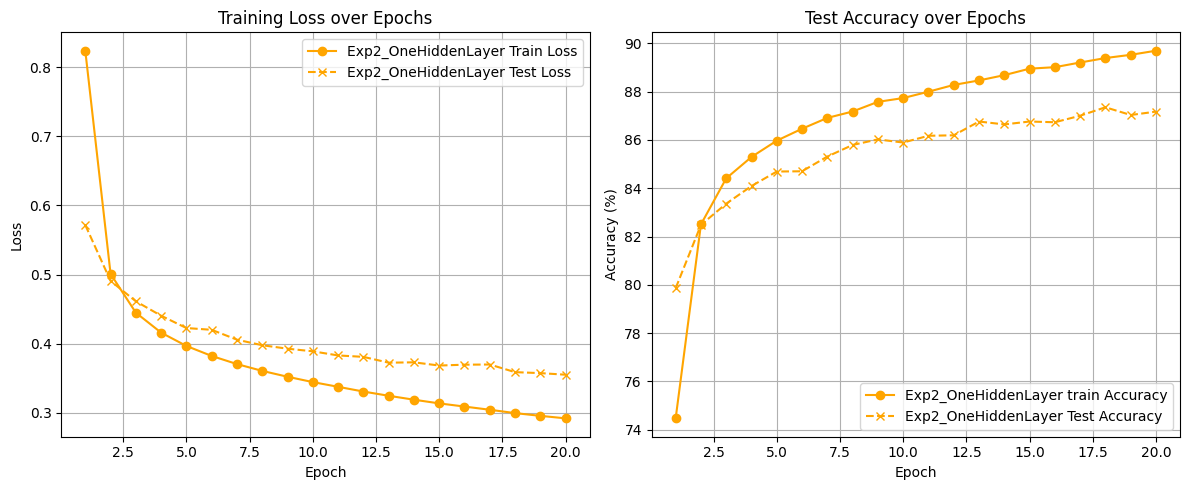

Exp2 final test accuracy: 87.17
Exp2 best test accuracy: 87.35


In [27]:
visualize(exp2, "Exp2_OneHiddenLayer", 20)

print("Exp2 final test accuracy:", exp2[3][-1])
print("Exp2 best test accuracy:", max(exp2[3]))

results_summary.append({
    "Experiment": "Exp2_OneHiddenLayer",
    "Final Train Loss": exp2[0][-1],
    "Final Test Loss": exp2[1][-1],
    "Final Train Accuracy": exp2[2][-1],
    "Final Test Accuracy": exp2[3][-1],
    "Best Test Accuracy": max(exp2[3])
})

## Experience 3

### Learning rate = 0.1

In [28]:
model_exp3 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp3 = nn.CrossEntropyLoss()
optimizer_exp3 = optim.SGD(model_exp3.parameters(), lr=0.1)

exp3 = train(
    model=model_exp3,
    epochs=20,
    optimizer=optimizer_exp3,
    criterion=criterion_exp3,
    train_loader=train_loader_norm_64,
    test_loader=test_loader_norm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 1.2696 | Test Loss: 0.7535 | Train Accuracy: 55.80 | Test Accuracy: 73.50%
Epoch [5/20] | Train Loss: 0.4003 | Test Loss: 0.4320 | Train Accuracy: 85.82 | Test Accuracy: 84.29%
Epoch [10/20] | Train Loss: 0.3173 | Test Loss: 0.3885 | Train Accuracy: 88.55 | Test Accuracy: 85.64%
Epoch [15/20] | Train Loss: 0.2800 | Test Loss: 0.3535 | Train Accuracy: 89.87 | Test Accuracy: 87.38%
Epoch [20/20] | Train Loss: 0.2544 | Test Loss: 0.3431 | Train Accuracy: 90.78 | Test Accuracy: 87.63%


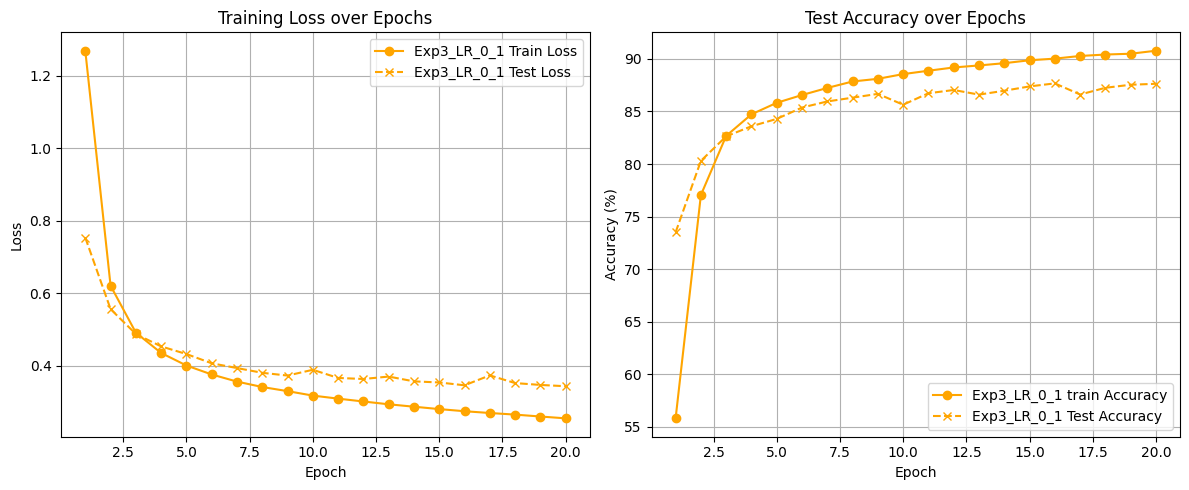

Exp3 final test accuracy: 87.63
Exp3 best test accuracy: 87.67


In [29]:
visualize(exp3, "Exp3_LR_0_1", 20)

print("Exp3 final test accuracy:", exp3[3][-1])
print("Exp3 best test accuracy:", max(exp3[3]))

results_summary.append({
    "Experiment": "Exp3_LR_0_1",
    "Final Train Loss": exp3[0][-1],
    "Final Test Loss": exp3[1][-1],
    "Final Train Accuracy": exp3[2][-1],
    "Final Test Accuracy": exp3[3][-1],
    "Best Test Accuracy": max(exp3[3])
})

### learning rate = 0.001

In [30]:
model_exp4 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp4 = nn.CrossEntropyLoss()
optimizer_exp4 = optim.SGD(model_exp4.parameters(), lr=0.001)

exp4 = train(
    model=model_exp4,
    epochs=20,
    optimizer=optimizer_exp4,
    criterion=criterion_exp4,
    train_loader=train_loader_norm_64,
    test_loader=test_loader_norm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 2.3079 | Test Loss: 2.2981 | Train Accuracy: 10.16 | Test Accuracy: 10.01%
Epoch [5/20] | Train Loss: 2.2642 | Test Loss: 2.2581 | Train Accuracy: 41.89 | Test Accuracy: 42.57%
Epoch [10/20] | Train Loss: 2.1712 | Test Loss: 2.1567 | Train Accuracy: 45.63 | Test Accuracy: 45.90%
Epoch [15/20] | Train Loss: 1.9750 | Test Loss: 1.9509 | Train Accuracy: 49.42 | Test Accuracy: 46.33%
Epoch [20/20] | Train Loss: 1.7383 | Test Loss: 1.7169 | Train Accuracy: 53.33 | Test Accuracy: 54.83%


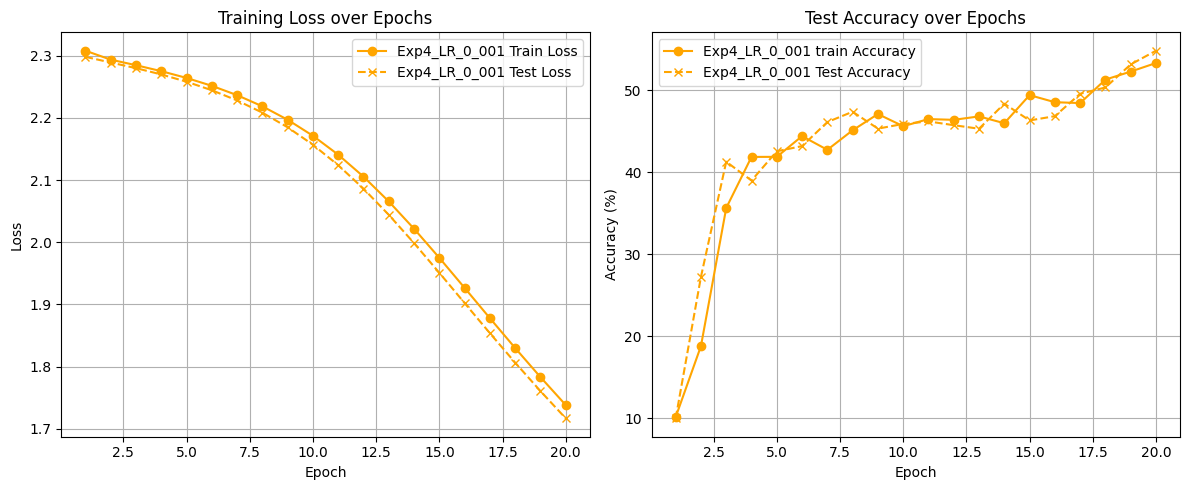

Exp4 final test accuracy: 54.83
Exp4 best test accuracy: 54.83


In [31]:
visualize(exp4, "Exp4_LR_0_001", 20)

print("Exp4 final test accuracy:", exp4[3][-1])
print("Exp4 best test accuracy:", max(exp4[3]))

results_summary.append({
    "Experiment": "Exp4_LR_0_001",
    "Final Train Loss": exp4[0][-1],
    "Final Test Loss": exp4[1][-1],
    "Final Train Accuracy": exp4[2][-1],
    "Final Test Accuracy": exp4[3][-1],
    "Best Test Accuracy": max(exp4[3])
})

## Experience 5

### Hinge loss

In [32]:
model_exp5 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp5 = hinge_loss_simple
optimizer_exp5 = optim.SGD(model_exp5.parameters(), lr=0.05)

exp5 = train(
    model=model_exp5,
    epochs=20,
    optimizer=optimizer_exp5,
    criterion=criterion_exp5,
    train_loader=train_loader_norm_64,
    test_loader=test_loader_norm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 1.4294 | Test Loss: 0.8037 | Train Accuracy: 68.66 | Test Accuracy: 77.68%
Epoch [5/20] | Train Loss: 0.4927 | Test Loss: 0.5458 | Train Accuracy: 86.17 | Test Accuracy: 85.06%
Epoch [10/20] | Train Loss: 0.3969 | Test Loss: 0.5322 | Train Accuracy: 88.39 | Test Accuracy: 85.53%
Epoch [15/20] | Train Loss: 0.3405 | Test Loss: 0.5223 | Train Accuracy: 89.74 | Test Accuracy: 86.08%
Epoch [20/20] | Train Loss: 0.3020 | Test Loss: 0.4600 | Train Accuracy: 90.57 | Test Accuracy: 87.80%


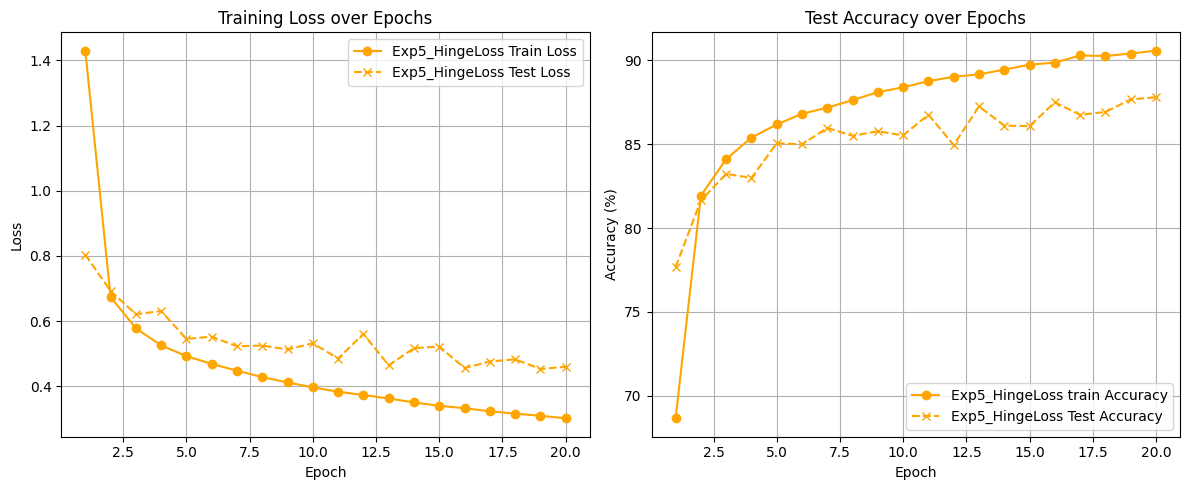

Exp5 final test accuracy: 87.8
Exp5 best test accuracy: 87.8


In [33]:
visualize(exp5, "Exp5_HingeLoss", 20)

print("Exp5 final test accuracy:", exp5[3][-1])
print("Exp5 best test accuracy:", max(exp5[3]))

results_summary.append({
    "Experiment": "Exp5_HingeLoss",
    "Final Train Loss": exp5[0][-1],
    "Final Test Loss": exp5[1][-1],
    "Final Train Accuracy": exp5[2][-1],
    "Final Test Accuracy": exp5[3][-1],
    "Best Test Accuracy": max(exp5[3])
})

### MSE loss

In [34]:
model_exp6 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp6 = mse_los
optimizer_exp6 = optim.SGD(model_exp6.parameters(), lr=0.05)

exp6 = train(
    model=model_exp6,
    epochs=20,
    optimizer=optimizer_exp6,
    criterion=criterion_exp6,
    train_loader=train_loader_norm_64,
    test_loader=test_loader_norm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 0.0901 | Test Loss: 0.0898 | Train Accuracy: 10.91 | Test Accuracy: 13.51%
Epoch [5/20] | Train Loss: 0.0891 | Test Loss: 0.0889 | Train Accuracy: 51.53 | Test Accuracy: 50.23%
Epoch [10/20] | Train Loss: 0.0866 | Test Loss: 0.0861 | Train Accuracy: 41.45 | Test Accuracy: 41.44%
Epoch [15/20] | Train Loss: 0.0800 | Test Loss: 0.0791 | Train Accuracy: 39.23 | Test Accuracy: 40.22%
Epoch [20/20] | Train Loss: 0.0704 | Test Loss: 0.0694 | Train Accuracy: 49.14 | Test Accuracy: 49.88%


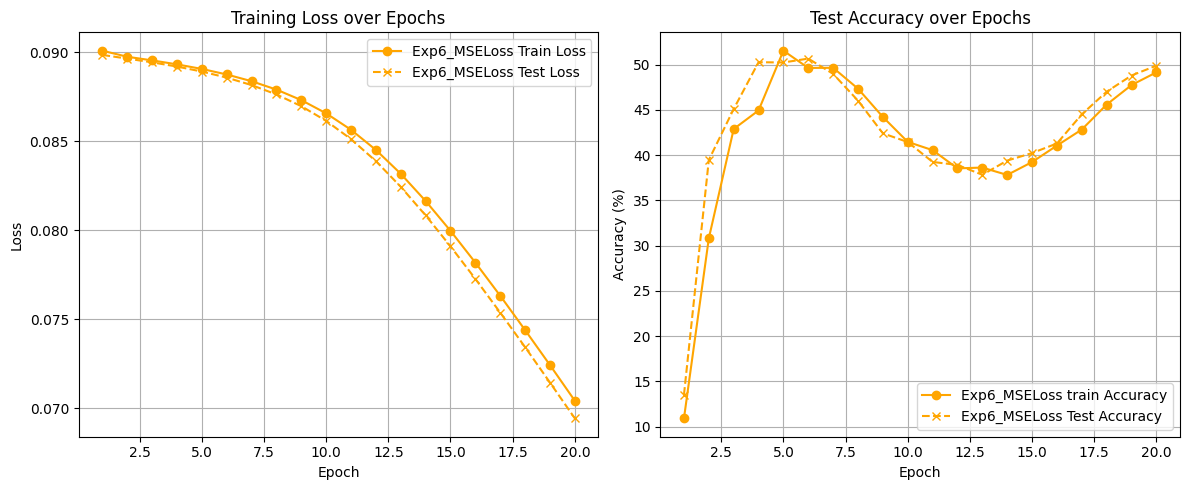

Exp6 final test accuracy: 49.88
Exp6 best test accuracy: 50.66


In [35]:
visualize(exp6, "Exp6_MSELoss", 20)

print("Exp6 final test accuracy:", exp6[3][-1])
print("Exp6 best test accuracy:", max(exp6[3]))

results_summary.append({
    "Experiment": "Exp6_MSELoss",
    "Final Train Loss": exp6[0][-1],
    "Final Test Loss": exp6[1][-1],
    "Final Train Accuracy": exp6[2][-1],
    "Final Test Accuracy": exp6[3][-1],
    "Best Test Accuracy": max(exp6[3])
})

## Experience 5

### h1 = 48, h2 = 300

In [36]:
model_exp7 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=48,
    h2_size=300,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp7 = nn.CrossEntropyLoss()
optimizer_exp7 = optim.SGD(model_exp7.parameters(), lr=0.05)

exp7 = train(
    model=model_exp7,
    epochs=20,
    optimizer=optimizer_exp7,
    criterion=criterion_exp7,
    train_loader=train_loader_norm_64,
    test_loader=test_loader_norm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 1.4895 | Test Loss: 0.9488 | Train Accuracy: 47.25 | Test Accuracy: 64.68%
Epoch [5/20] | Train Loss: 0.4586 | Test Loss: 0.4850 | Train Accuracy: 83.77 | Test Accuracy: 82.73%
Epoch [10/20] | Train Loss: 0.3687 | Test Loss: 0.4200 | Train Accuracy: 86.78 | Test Accuracy: 84.69%
Epoch [15/20] | Train Loss: 0.3303 | Test Loss: 0.3819 | Train Accuracy: 88.15 | Test Accuracy: 86.27%
Epoch [20/20] | Train Loss: 0.3053 | Test Loss: 0.3670 | Train Accuracy: 88.97 | Test Accuracy: 86.75%


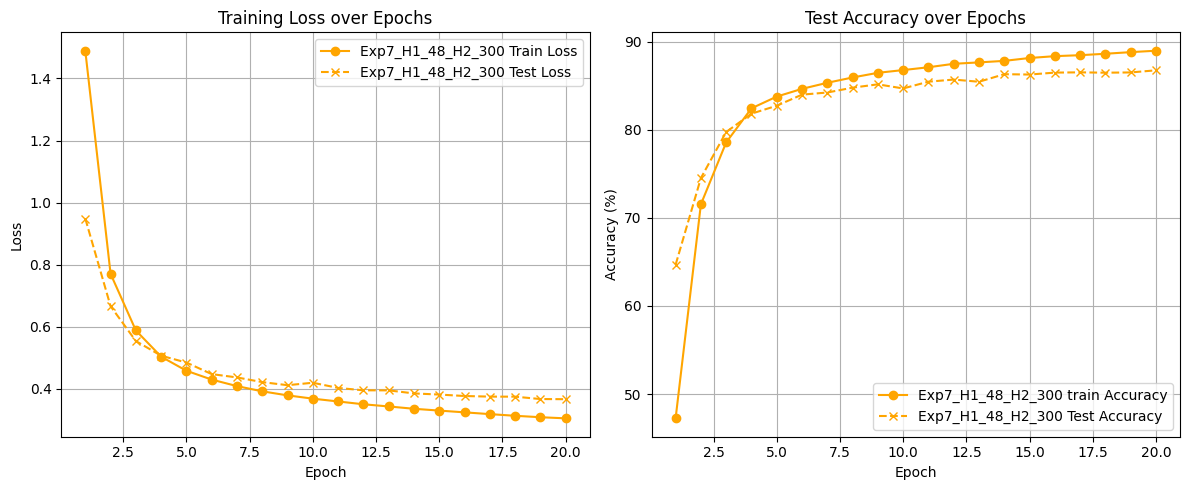

Exp7 final test accuracy: 86.75
Exp7 best test accuracy: 86.75


In [37]:
visualize(exp7, "Exp7_H1_48_H2_300", 20)

print("Exp7 final test accuracy:", exp7[3][-1])
print("Exp7 best test accuracy:", max(exp7[3]))

results_summary.append({
    "Experiment": "Exp7_H1_48_H2_300",
    "Final Train Loss": exp7[0][-1],
    "Final Test Loss": exp7[1][-1],
    "Final Train Accuracy": exp7[2][-1],
    "Final Test Accuracy": exp7[3][-1],
    "Best Test Accuracy": max(exp7[3])
})

### h1 = 300, h2 = 48

In [38]:
model_exp8 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=300,
    h2_size=48,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp8 = nn.CrossEntropyLoss()
optimizer_exp8 = optim.SGD(model_exp8.parameters(), lr=0.05)

exp8 = train(
    model=model_exp8,
    epochs=20,
    optimizer=optimizer_exp8,
    criterion=criterion_exp8,
    train_loader=train_loader_norm_64,
    test_loader=test_loader_norm_64,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 1.5286 | Test Loss: 1.0072 | Train Accuracy: 49.00 | Test Accuracy: 64.44%
Epoch [5/20] | Train Loss: 0.4916 | Test Loss: 0.5004 | Train Accuracy: 82.58 | Test Accuracy: 82.00%
Epoch [10/20] | Train Loss: 0.3897 | Test Loss: 0.4264 | Train Accuracy: 86.18 | Test Accuracy: 84.57%
Epoch [15/20] | Train Loss: 0.3443 | Test Loss: 0.3904 | Train Accuracy: 87.72 | Test Accuracy: 86.01%
Epoch [20/20] | Train Loss: 0.3144 | Test Loss: 0.3843 | Train Accuracy: 88.85 | Test Accuracy: 86.48%


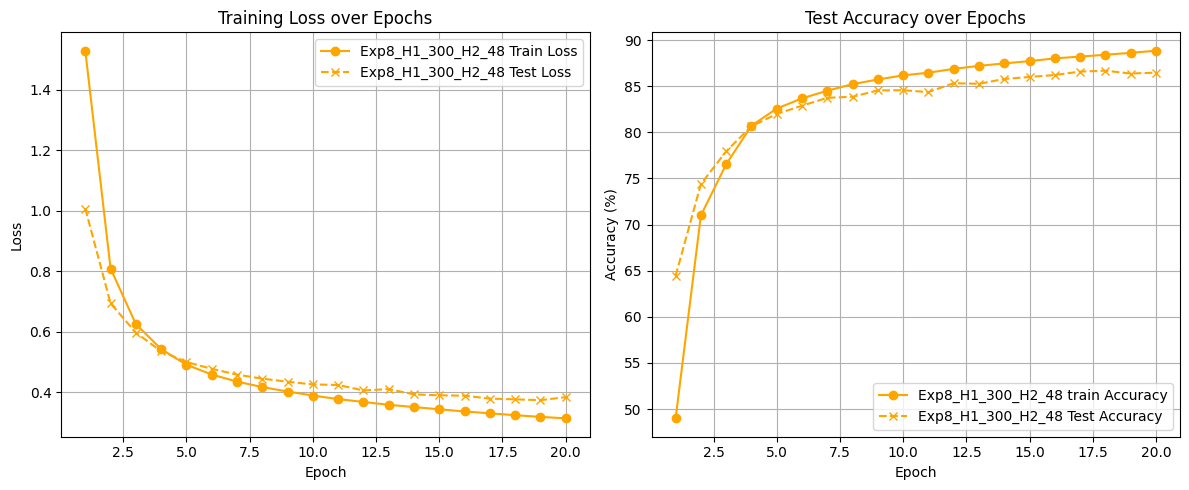

Exp8 final test accuracy: 86.48
Exp8 best test accuracy: 86.69


In [39]:
visualize(exp8, "Exp8_H1_300_H2_48", 20)

print("Exp8 final test accuracy:", exp8[3][-1])
print("Exp8 best test accuracy:", max(exp8[3]))

results_summary.append({
    "Experiment": "Exp8_H1_300_H2_48",
    "Final Train Loss": exp8[0][-1],
    "Final Test Loss": exp8[1][-1],
    "Final Train Accuracy": exp8[2][-1],
    "Final Test Accuracy": exp8[3][-1],
    "Best Test Accuracy": max(exp8[3])
})

## Experience 6

In [40]:
model_exp9 = FashionMLP(
    input_size=INPUT_SIZE,
    h1_size=64,
    h2_size=64,
    output_size=OUTPUT_SIZE,
    activation1=ACTIVATION1,
    activation2=ACTIVATION2
).to(device)

criterion_exp9 = nn.CrossEntropyLoss()
optimizer_exp9 = optim.SGD(model_exp9.parameters(), lr=0.05)

exp9 = train(
    model=model_exp9,
    epochs=20,
    optimizer=optimizer_exp9,
    criterion=criterion_exp9,
    train_loader=train_loader_norm_8,
    test_loader=test_loader_norm_8,
    device=device
)

Starting training...
Epoch [1/20] | Train Loss: 0.7242 | Test Loss: 0.4778 | Train Accuracy: 73.64 | Test Accuracy: 83.11%
Epoch [5/20] | Train Loss: 0.3217 | Test Loss: 0.3835 | Train Accuracy: 88.16 | Test Accuracy: 86.17%
Epoch [10/20] | Train Loss: 0.2649 | Test Loss: 0.3485 | Train Accuracy: 90.10 | Test Accuracy: 87.34%
Epoch [15/20] | Train Loss: 0.2311 | Test Loss: 0.3677 | Train Accuracy: 91.43 | Test Accuracy: 87.70%
Epoch [20/20] | Train Loss: 0.2062 | Test Loss: 0.3686 | Train Accuracy: 92.31 | Test Accuracy: 87.60%


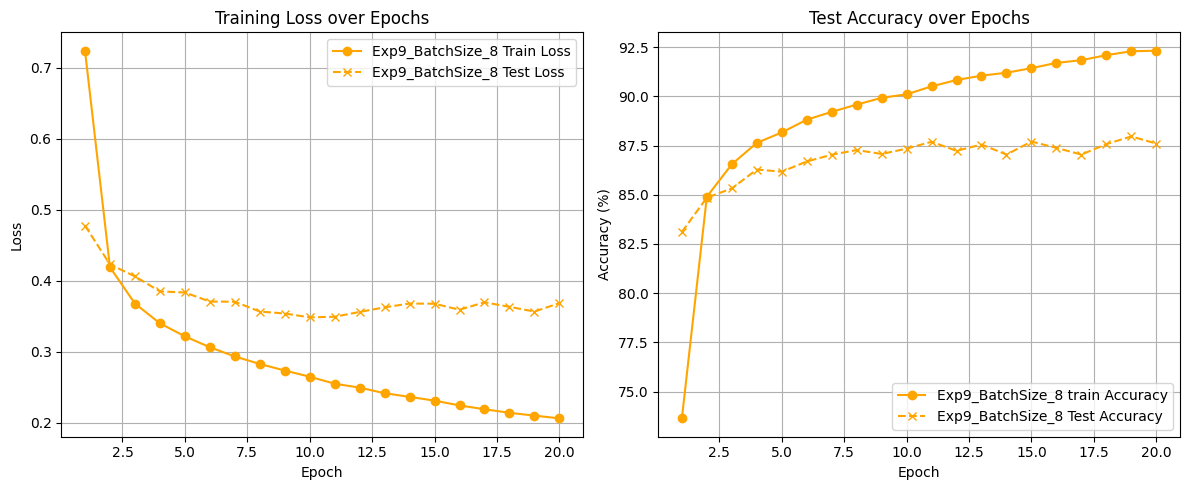

Exp9 final test accuracy: 87.6
Exp9 best test accuracy: 87.96


In [41]:
visualize(exp9, "Exp9_BatchSize_8", 20)

print("Exp9 final test accuracy:", exp9[3][-1])
print("Exp9 best test accuracy:", max(exp9[3]))

results_summary.append({
    "Experiment": "Exp9_BatchSize_8",
    "Final Train Loss": exp9[0][-1],
    "Final Test Loss": exp9[1][-1],
    "Final Train Accuracy": exp9[2][-1],
    "Final Test Accuracy": exp9[3][-1],
    "Best Test Accuracy": max(exp9[3])
})

## End

In [42]:
import pandas as pd

summary_df = pd.DataFrame(results_summary)
summary_df

,Experiment,Final Train Loss,Final Test Loss,Final Train Accuracy,Final Test Accuracy,Best Test Accuracy
0,Baseline,0.301517,0.385789,89.248333,86.35,86.94
1,Exp1_NoNormalization,0.397095,0.455276,85.876667,83.97,84.40
2,Exp2_OneHiddenLayer,0.291963,0.355085,89.691667,87.17,87.35
3,Exp3_LR_0_1,0.254441,0.343115,90.776667,87.63,87.67
4,Exp4_LR_0_001,1.738320,1.716931,53.330000,54.83,54.83
5,Exp5_HingeLoss,0.301951,0.460013,90.573333,87.80,87.80
6,Exp6_MSELoss,0.070420,0.069429,49.140000,49.88,50.66
7,Exp7_H1_48_H2_300,0.305310,0.366966,88.975000,86.75,86.75
8,Exp8_H1_300_H2_48,0.314380,0.384327,88.853333,86.48,86.69
9,Exp9_BatchSize_8,0.206195,0.368562,92.315000,87.60,87.96


In [43]:
summary_df.sort_values(by="Best Test Accuracy", ascending=False)

,Experiment,Final Train Loss,Final Test Loss,Final Train Accuracy,Final Test Accuracy,Best Test Accuracy
9,Exp9_BatchSize_8,0.206195,0.368562,92.315000,87.60,87.96
5,Exp5_HingeLoss,0.301951,0.460013,90.573333,87.80,87.80
3,Exp3_LR_0_1,0.254441,0.343115,90.776667,87.63,87.67
2,Exp2_OneHiddenLayer,0.291963,0.355085,89.691667,87.17,87.35
0,Baseline,0.301517,0.385789,89.248333,86.35,86.94
7,Exp7_H1_48_H2_300,0.305310,0.366966,88.975000,86.75,86.75
8,Exp8_H1_300_H2_48,0.314380,0.384327,88.853333,86.48,86.69
1,Exp1_NoNormalization,0.397095,0.455276,85.876667,83.97,84.40
4,Exp4_LR_0_001,1.738320,1.716931,53.330000,54.83,54.83
6,Exp6_MSELoss,0.070420,0.069429,49.140000,49.88,50.66


In [45]:
print("Baseline vs Exp1_NoNormalization")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp1 best test accuracy:", max(exp1[3]))
print()

print("Baseline vs Exp2_OneHiddenLayer")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp2 best test accuracy:", max(exp2[3]))
print()

print("Baseline vs Exp3_LR_0_1")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp3 best test accuracy:", max(exp3[3]))
print()

print("Baseline vs Exp4_LR_0_001")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp4 best test accuracy:", max(exp4[3]))
print()

print("Baseline vs Exp5_HingeLoss")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp5 best test accuracy:", max(exp5[3]))
print()

print("Baseline vs Exp6_MSELoss")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp6 best test accuracy:", max(exp6[3]))
print()

print("Baseline vs Exp7_H1_48_H2_300")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp7 best test accuracy:", max(exp7[3]))
print()

print("Baseline vs Exp8_H1_300_H2_48")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp8 best test accuracy:", max(exp8[3]))
print()

print("Baseline vs Exp9_BatchSize_8")
print("Baseline best test accuracy:", max(baseline_experiment[3]))
print("Exp9 best test accuracy:", max(exp9[3]))

Baseline vs Exp1_NoNormalization
Baseline best test accuracy: 86.94
Exp1 best test accuracy: 84.4

Baseline vs Exp2_OneHiddenLayer
Baseline best test accuracy: 86.94
Exp2 best test accuracy: 87.35

Baseline vs Exp3_LR_0_1
Baseline best test accuracy: 86.94
Exp3 best test accuracy: 87.67

Baseline vs Exp4_LR_0_001
Baseline best test accuracy: 86.94
Exp4 best test accuracy: 54.83

Baseline vs Exp5_HingeLoss
Baseline best test accuracy: 86.94
Exp5 best test accuracy: 87.8

Baseline vs Exp6_MSELoss
Baseline best test accuracy: 86.94
Exp6 best test accuracy: 50.66

Baseline vs Exp7_H1_48_H2_300
Baseline best test accuracy: 86.94
Exp7 best test accuracy: 86.75

Baseline vs Exp8_H1_300_H2_48
Baseline best test accuracy: 86.94
Exp8 best test accuracy: 86.69

Baseline vs Exp9_BatchSize_8
Baseline best test accuracy: 86.94
Exp9 best test accuracy: 87.96
